In [51]:
import sys 
print(sys.version)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
print("pandas loaded chat")
import numpy as np

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
pandas loaded chat


In [31]:
pd.set_option("display.max_columns",None)
df = pd.read_csv("C:/Users/sovit/Downloads/Telegram Desktop/sch notes/excel practice/funnel/data/ecommerce_customer_behavior_dataset.csv")
##loading data set

In [32]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [25]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

(5000, 18)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.isnull().sum()
##no missing / duplicated data 

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [6]:
df.describe(include="all").T #give summary statistics for all columns, transposed for readability
#every row has count=5000 -> no missing data
#what insights can i draw from this??


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,5000,5000,ORD_001337,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,5000,5000,CUST_01337,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,5000,451,2023-07-14,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5000.0,NaN,NaN,NaN,35.0326,11.080546,18.0,27.0,35.0,42.0,75.0
Gender,5000,3,Female,2492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5000,10,Istanbul,1284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,5000,8,Sports,667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit_Price,5000.0,NaN,NaN,NaN,455.83412,712.477209,5.18,76.5875,182.95,513.93,7159.45
Quantity,5000.0,NaN,NaN,NaN,2.22,1.398711,1.0,1.0,2.0,3.0,5.0
Discount_Amount,5000.0,NaN,NaN,NaN,24.852804,88.385124,0.0,0.0,0.0,8.76,1525.55


In [37]:
##format date to weekday / weekends 
df["Date"] = pd.to_datetime(df["Date"])

In [38]:
df["Month"] = df["Date"].dt.month

In [42]:
df["Day"] = df["Date"].dt.day_name()

In [ ]:
df["Weekend"] = df["Day"].isin(["Saturday","Sunday"])  ##True = Weekend 
##check if customers spend more on weekend vs weekday 

In [44]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Month,Weekday,Day,Weekend
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,1,Sunday,Sunday,True
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,1,Sunday,Sunday,True
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,1,Sunday,Sunday,True
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,1,Sunday,Sunday,True
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,1,Sunday,Sunday,True


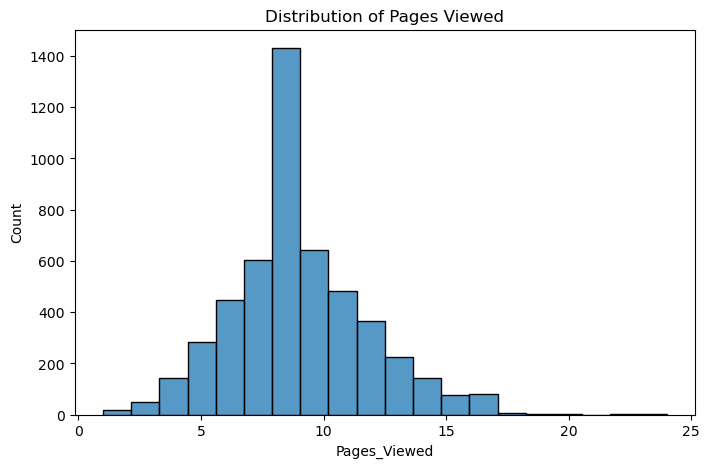

In [49]:
## tiering customer engagement (using pages viewed)
plt.figure(figsize=(8,5))
sns.histplot(df["Pages_Viewed"],bins=20) 
plt.title("Distribution of Pages Viewed")
plt.show()

In [55]:
df["Pages_Viewed"].describe()

count    5000.00000
mean        8.98420
std         2.80434
min         1.00000
25%         7.00000
50%         9.00000
75%        11.00000
max        24.00000
Name: Pages_Viewed, dtype: float64

In [85]:

bins = [0, 5, 10, float('inf')]
labels = ['Low', 'Medium', 'High']

df['Engagement_Level'] = pd.cut(
    df['Pages_Viewed'],
    bins=bins,
    labels=labels,
    right=True      
)
##engagement level column created

In [84]:
high_value = df["Total_Amount"].quantile(0.75)
df["high_value"] = df["Total_Amount"] >= high_value
print(high_value)
## created high value column, True = high value purchase 

979.6949999999999


In [87]:
#######VOID####################

df["high_engagement"] = df["Engagement_Level"] == "High"
##created a high engagement column

In [88]:
print(df["Engagement_Level"].value_counts())
print(df["high_engagement"].value_counts())
print(df["high_engagement"].dtype)

Engagement_Level
Medium    3124
High      1382
Low        494
Name: count, dtype: int64
high_engagement
False    3618
True     1382
Name: count, dtype: int64
bool


In [70]:
df.head()
##ok now we have two new columns to indicate high_value & high_engagement customers 

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Month,Weekday,Day,Weekend,Engagement_Level,high_value,high_engagement
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,1,Sunday,Sunday,True,High,False,True
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,1,Sunday,Sunday,True,High,False,True
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,1,Sunday,Sunday,True,High,False,True
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,1,Sunday,Sunday,True,High,False,True
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,1,Sunday,Sunday,True,High,True,True


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

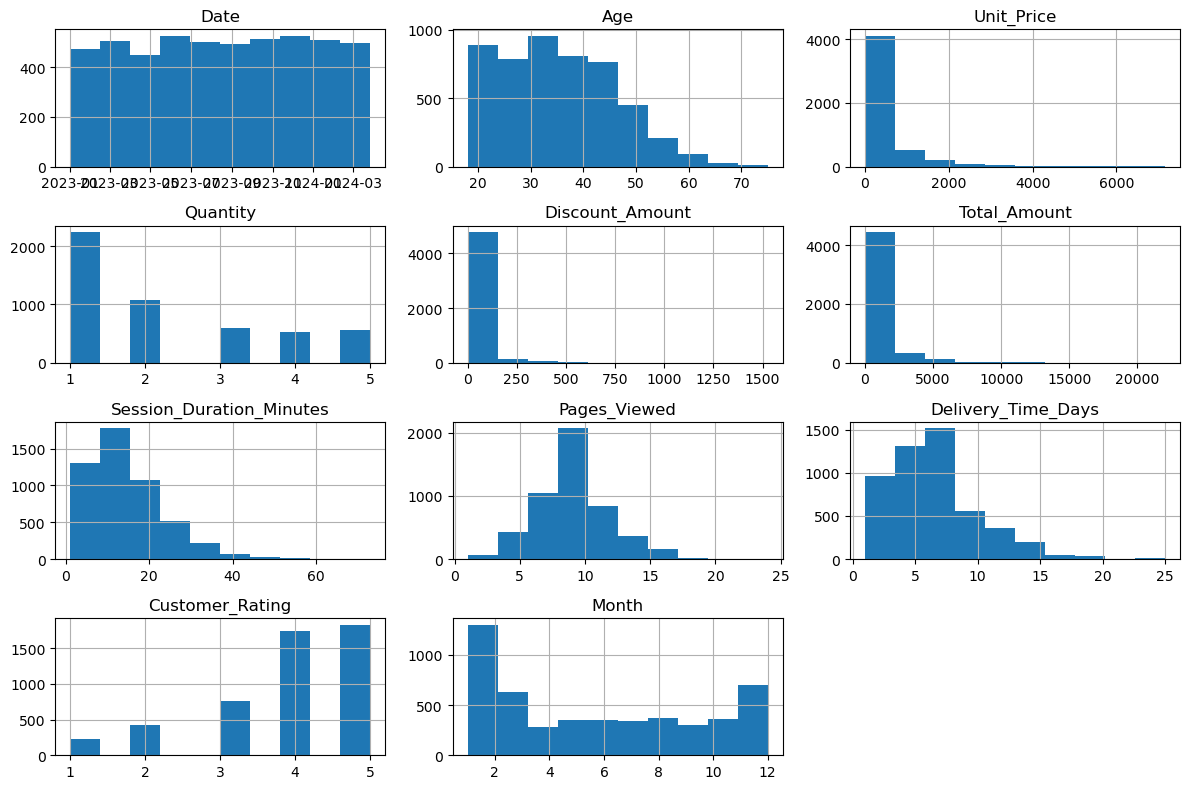

In [69]:
df.hist(figsize=(12,8)) #creates histogram for all numeric columns 
plt.tight_layout() #adjust spacing so graphs are readable
plt.show()
#total amount is right skewed, mean is useless. good for funnel tiering (??) 
#session duration is also right skewed, but the distribution is quite even

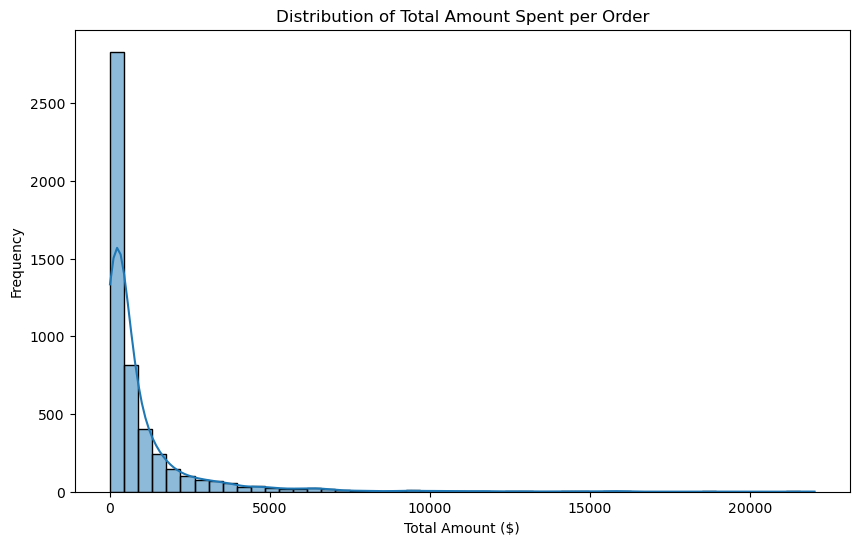

In [71]:
#starting EDA 
#distribution plots 
#distribution of total amount spent per order 
plt.figure(figsize=(10,6))
sns.histplot(df['Total_Amount'], bins=50, kde=True)
plt.title('Distribution of Total Amount Spent per Order')
plt.xlabel('Total Amount ($)')
plt.ylabel('Frequency')
plt.show()

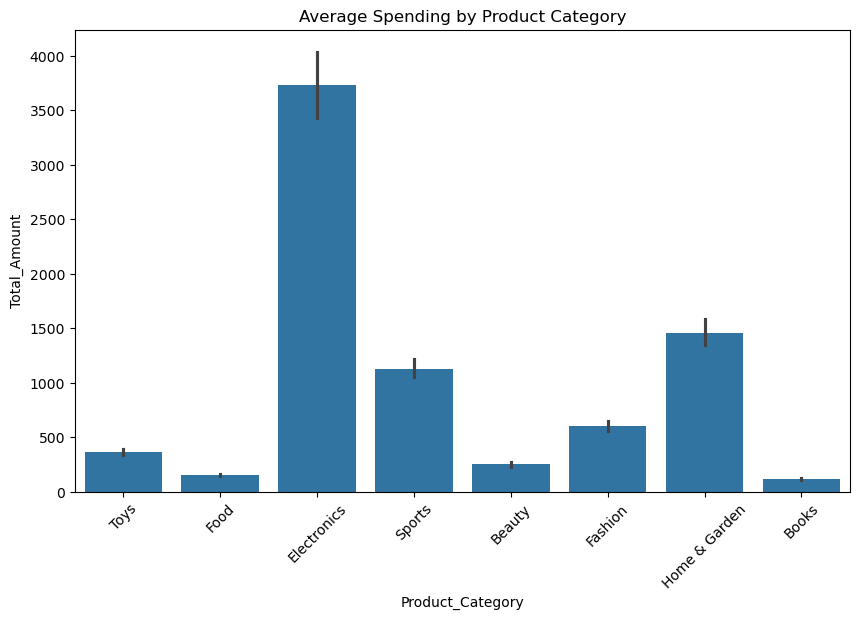

In [74]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Product_Category", y="Total_Amount", estimator="mean")
plt.xticks(rotation=45)
plt.title("Average Spending by Product Category")
plt.show()

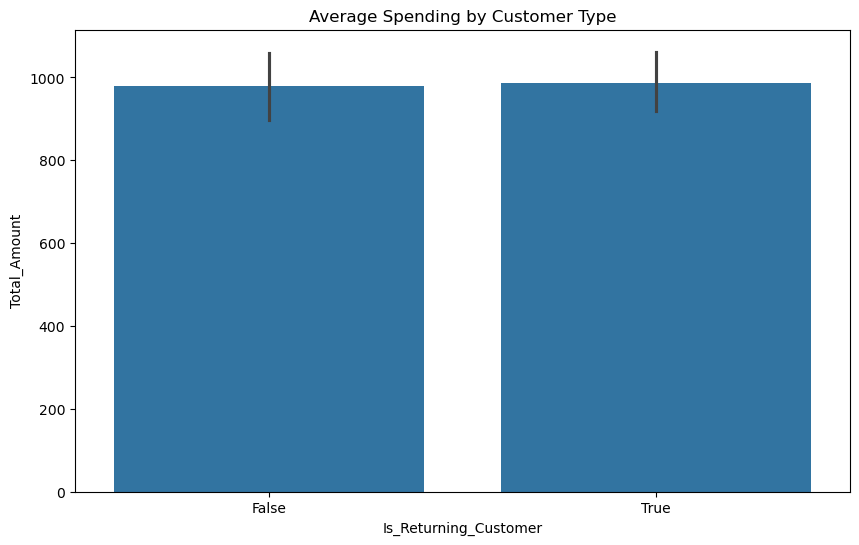

In [75]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Is_Returning_Customer", y="Total_Amount", estimator="mean")
plt.title("Average Spending by Customer Type")
plt.show()

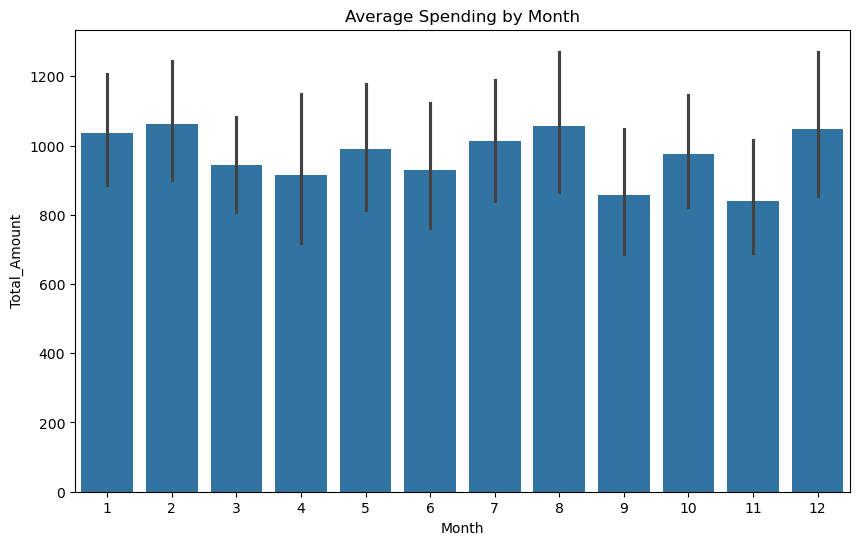

In [76]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Month", y="Total_Amount", estimator="mean")
plt.title("Average Spending by Month")
plt.show()

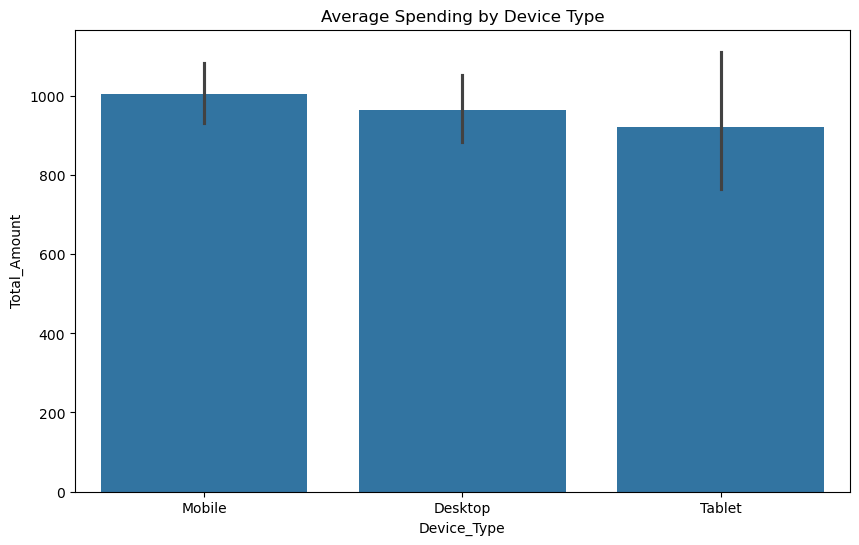

In [77]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Device_Type", y="Total_Amount", estimator="mean")
plt.title("Average Spending by Device Type")
plt.show()

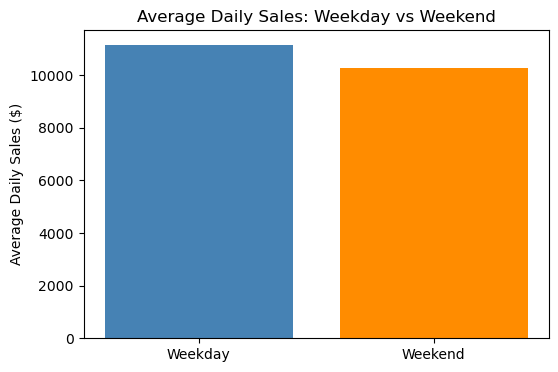

In [78]:
avg_weekend = df[df['Weekend']]['Total_Amount'].sum() / df[df['Weekend']]['Date'].nunique()
avg_weekday = df[~df['Weekend']]['Total_Amount'].sum() / df[~df['Weekend']]['Date'].nunique()

plt.figure(figsize=(6,4))
plt.bar(['Weekday', 'Weekend'], [avg_weekday, avg_weekend], color=['steelblue', 'darkorange'])
plt.ylabel('Average Daily Sales ($)')
plt.title('Average Daily Sales: Weekday vs Weekend')
plt.show()

In [90]:
## we can see the main driver is the category of products 
## for funnel, do we do a category funnel? customer funnel? 
total_orders = len(df)
high_engaged_orders = (df["Engagement_Level"] == "High").sum()
high_value_orders = df["high_value"].sum() ##high value purchases

total_orders, high_engaged_orders, high_value_orders

(5000, np.int64(1382), np.int64(1250))

In [93]:
engagement_rate = high_engaged_orders / total_orders
high_value_rate = high_value_orders / total_orders

engagement_rate, high_value_rate

(np.float64(0.2764), np.float64(0.25))

In [ ]:
##crosstab then chi square to see p value (see if significant or not) 
## then possibly do another funnel because this concludes a weak correlation ! then add some business insights :D 